# 7.0 - Meta-learning: data efficiency vs the best CL method

The DATA-EFFICIENCY axis. The best continual method so far, Replay+LwF (notebook 4.6),
reached 77% AA using the FULL task data - about 95 clips per class. Meta-learning learns a
new class from a handful of examples. So: how much accuracy survives when you use far fewer
samples, and which method wins at a small budget?

TASK_4 is 10 classes no notebook has touched - free held-out data. On it we measure a
full-data reference and three few-shot arms at K in {1, 5, 10} shots per class:

- **full fine-tune**    : train on ALL ~95 clips/class (the full-data reference)
- **standard fine-tune**: train on the K shots (few-shot baseline, not meta-learning)
- **Reptile**           : optimisation-based meta-learning, inner-loop SGD then averaging
- **ProtoNet**          : metric-based, class = mean embedding, nearest prototype, no training

Reptile and fine-tune adapt the LSTM+head; ProtoNet does not touch it - the SimpleCIL-style
frozen-feature baseline. With the backbone frozen and only a few shots, the no-training
prototype should be hard to beat, especially at K=1 where gradient methods overfit their
single example. All arms consume the same Task-0 representation, so the comparison is fair.

## **Connect Colab**

In [1]:
import os, sys, subprocess
from getpass import getpass

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "embeddings"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [ ]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "PASTE_YOUR_KAGGLE_KEY"

## **Download DATASET**

TASK_4 clips are needed, so the dataset is downloaded here.

In [3]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

Drive mounted.
Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
ULAL_DATASET_ROOT = /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/
ULAL_OUTPUT_ROOT  = /content/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


In [4]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
GPU       : Tesla T4 (15.6 GB)
Classes   : base=10 t1=10 t2=10 t3=10 t4=10


42

## **Preprocess data**

TASK_4 on a group-disjoint split, exactly like every other task. Labels are local 0-9
because TASK_4 is treated as its own 10-way problem here.

In [ ]:
leaking = check_group_leakage(cfg.TASK_4)

classes checked : 10
videos          : 1346
groups          : 250
groups in >1 split: 184

LEAKAGE: 73.6% of groups span multiple splits.
Clips from one source video are in both train and test, so every
accuracy and the probe ceiling are inflated. Re-split by group.
  v_BaseballPitch_g01                ['train', 'val']
  v_BaseballPitch_g02                ['train', 'val']
  v_BaseballPitch_g03                ['train', 'val']
  v_BaseballPitch_g05                ['test', 'train']
  v_BaseballPitch_g06                ['test', 'train']
  v_BaseballPitch_g07                ['test', 'train', 'val']
  v_BaseballPitch_g10                ['test', 'train']
  v_BaseballPitch_g12                ['test', 'train']
  v_BaseballPitch_g13                ['test', 'train']
  v_BaseballPitch_g14                ['train', 'val']


In [6]:
task4_split = build_group_split(cfg.TASK_4, train_groups=18, val_groups=3)

In [ ]:
clashes = describe_group_split(task4_split, cfg.TASK_4)

split      clips   percent  clips/class
---------------------------------------
train        974     72.4%         97.4
val          158     11.7%         15.8
test         214     15.9%         21.4
---------------------------------------
TOTAL       1346                  134.6

groups: 250   groups in >1 split: 0
OK - group-disjoint.


Do not run the next cell unless the check says `OK - group-disjoint`.

In [8]:
preprocess_group_split(task4_split, cfg.TASK_4, output_root=cfg.TASK4_ROOT)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task4
Classes: 10

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: /content/UCF101/grouped_task4


In [9]:
class_to_idx_t4 = {cls_name: i for i, cls_name in enumerate(cfg.TASK_4)}
print(f"class_to_idx_t4:\n{class_to_idx_t4}")

class_to_idx_t4:
{'PlayingPiano': 0, 'PlayingGuitar': 1, 'HulaHoop': 2, 'GolfSwing': 3, 'Fencing': 4, 'CleanAndJerk': 5, 'Billiards': 6, 'Biking': 7, 'BenchPress': 8, 'BaseballPitch': 9}


## **Upload Model**

The frozen teacher, loaded the way notebook 2.0 loads it. Only its backbone is used, to
turn TASK_4 clips into (16, 2048) features.

In [10]:
cfg.RESNET50_PATH = f"{cfg.DRIVE_PROJECT}/resnet50/models/ResNet50_10C_groupsplit.pth"

teacher = ResNet50LSTMTeacher(
    hidden_size = cfg.TEACHER_HIDDEN,
    num_classes = len(cfg.SELECTED_CLASSES),
    dropout_p   = cfg.DROPOUT_P,
).to(device)

mapped = remap_teacher_checkpoint(torch.load(cfg.RESNET50_PATH, map_location=device))
teacher.load_state_dict(mapped, strict=False)
for p in teacher.parameters():
    p.requires_grad_(False)
teacher.eval()
print("teacher frozen")

  Dropped 53 num_batches_tracked buffer(s).
teacher frozen


In [11]:
CACHE, LSTM_STATE, META = load_feature_cache(cfg.FEAT_CACHE)
print("LSTM state loaded (shared init for both heads)")

Loaded 9 tensors, 526 MB in RAM
  per clip: (16, 2048)
LSTM state loaded (shared init for both heads)


## **Extract TASK_4 Features**

Run the frozen backbone over TASK_4 and keep the (16, 2048) features per clip. Train, val
and test are cached separately, as always.

In [12]:
PIN = device.type == "cuda"
t4_train_ds, t4_train_loader = build_clip_loader(cfg.TASK4_ROOT, cfg.TASK_4, class_to_idx_t4, "train", cfg.BATCH_SIZE, cfg.NUM_WORKERS, PIN)
t4_val_ds,   t4_val_loader   = build_clip_loader(cfg.TASK4_ROOT, cfg.TASK_4, class_to_idx_t4, "val",   cfg.BATCH_SIZE, cfg.NUM_WORKERS, PIN)
t4_test_ds,  t4_test_loader  = build_clip_loader(cfg.TASK4_ROOT, cfg.TASK_4, class_to_idx_t4, "test",  cfg.BATCH_SIZE, cfg.NUM_WORKERS, PIN)

print(f"train {len(t4_train_ds)}  val {len(t4_val_ds)}  test {len(t4_test_ds)}")

train 974  val 158  test 214


In [13]:
train_s, train_y = extract_frame_features(teacher.backbone, t4_train_loader, device, cfg.BACKBONE_DIM, torch.float32)
val_s,   val_y   = extract_frame_features(teacher.backbone, t4_val_loader,   device, cfg.BACKBONE_DIM, torch.float32)
test_s,  test_y  = extract_frame_features(teacher.backbone, t4_test_loader,  device, cfg.BACKBONE_DIM, torch.float32)

print(f"train {tuple(train_s.shape)}  val {tuple(val_s.shape)}  test {tuple(test_s.shape)}")

  Frame features: 100%|██████████| 27/27 [00:11<00:00,  2.27it/s]

train (974, 16, 2048)  val (158, 16, 2048)  test (214, 16, 2048)


## **Full-data Reference**

Train the same head on ALL of TASK_4's clips - the full-data ceiling for these 10 classes,
and the data budget the best CL method (Replay+LwF) uses per task. Every few-shot number is
read against this.

In [14]:
set_seed(cfg.SEED)
head_full = make_temporal_head(len(cfg.TASK_4), lstm_state=LSTM_STATE, device=device)
finetune_head(head_full, train_s, None, train_y, val_s, val_y, device,
              epochs=cfg.FINETUNE_EPOCHS, lr=cfg.FINETUNE_LR, wd=cfg.FINETUNE_WD,
              batch_size=cfg.FINETUNE_BATCH, patience=cfg.FINETUNE_PATIENCE,
              ce_weight=1.0, mse_weight=0.0)
acc_full   = eval_head(head_full, test_s, test_y, device)
SHOTS_FULL = len(train_y) / len(cfg.TASK_4)
print(f"full data: {SHOTS_FULL:.0f} clips/class -> {acc_full:.2%}")

[FineTune] Epoch 01/15 | Train: 96.10% | Val: 88.61% | Loss: 0.7216
[FineTune] Epoch 02/15 | Train: 99.18% | Val: 92.41% | Loss: 0.8272
[FineTune] Epoch 03/15 | Train: 99.38% | Val: 94.94% | Loss: 0.7114
[FineTune] Epoch 04/15 | Train: 99.79% | Val: 94.30% | Loss: 0.7220
[FineTune] Epoch 05/15 | Train: 99.90% | Val: 95.57% | Loss: 0.8406
[FineTune] Epoch 06/15 | Train: 100.00% | Val: 96.20% | Loss: 0.7104
[FineTune] Epoch 07/15 | Train: 99.90% | Val: 95.57% | Loss: 0.7107
[FineTune] Epoch 08/15 | Train: 100.00% | Val: 96.20% | Loss: 0.6976
[FineTune] Epoch 09/15 | Train: 100.00% | Val: 94.94% | Loss: 0.7052
[FineTune] Epoch 10/15 | Train: 100.00% | Val: 96.84% | Loss: 0.7070
[FineTune] Epoch 11/15 | Train: 100.00% | Val: 96.84% | Loss: 0.7132
[FineTune] Epoch 12/15 | Train: 100.00% | Val: 96.84% | Loss: 0.6963
[FineTune] Epoch 13/15 | Train: 100.00% | Val: 96.84% | Loss: 0.6996
[FineTune] Epoch 14/15 | Train: 100.00% | Val: 96.84% | Loss: 0.6968
[FineTune] Epoch 15/15 | Train: 100.00% 

## **Few-shot Probe**

For each K, the train pool is cut to K clips per class. The standard head is fine-tuned on
those K shots; the Reptile head is meta-trained on episodes drawn from them; ProtoNet just
embeds them into prototypes. All three use the same Task-0 LSTM and are measured on the full
TASK_4 test set. There is no teacher target for TASK_4, so the MSE term is off.

In [15]:
K_LIST  = [1, 5, 10]
t_train = torch.zeros(len(train_y), cfg.TEACHER_HIDDEN)
TRIALS  = []

In [16]:
for K in K_LIST:
    k_s, k_t, k_y = limit_to_k_per_class(train_s, t_train, train_y, K, cfg.SEED)

    set_seed(cfg.SEED)
    head_std = make_temporal_head(len(cfg.TASK_4), lstm_state=LSTM_STATE, device=device)
    finetune_head(head_std, k_s, None, k_y, val_s, val_y, device,
                  epochs=cfg.FINETUNE_EPOCHS, lr=cfg.FINETUNE_LR, wd=cfg.FINETUNE_WD,
                  batch_size=cfg.FINETUNE_BATCH, patience=cfg.FINETUNE_PATIENCE,
                  ce_weight=1.0, mse_weight=0.0)
    acc_std = eval_head(head_std, test_s, test_y, device)

    set_seed(cfg.SEED)
    head_rep = make_temporal_head(len(cfg.TASK_4), lstm_state=LSTM_STATE, device=device)
    train_reptile(head_rep, k_s, k_t, k_y, val_s, val_y, len(cfg.TASK_4), device,
                  reptile_epochs=cfg.REPTILE_EPOCHS, episodes_per_epoch=cfg.EPISODES_PER_EPOCH,
                  k_support=min(K, cfg.K_SUPPORT), k_query=0, inner_lr=cfg.INNER_LR,
                  inner_steps=cfg.INNER_STEPS, src_epsilon=cfg.SRC_EPSILON,
                  ce_weight=1.0, mse_weight=0.0, reptile_patience=cfg.REPTILE_PATIENCE)
    acc_rep = eval_head(head_rep, test_s, test_y, device)

    set_seed(cfg.SEED)
    head_proto = make_temporal_head(len(cfg.TASK_4), lstm_state=LSTM_STATE, device=device)
    acc_proto  = proto_eval(head_proto, k_s, k_y, test_s, test_y, device)

    TRIALS.append({"K": K, "standard": float(acc_std), "reptile": float(acc_rep),
                   "protonet": float(acc_proto)})
    print(f"\nK={K:>2} | standard {acc_std:.2%} | reptile {acc_rep:.2%} | protonet {acc_proto:.2%}\n")

[FineTune] Epoch 01/15 | Train: 80.00% | Val: 33.54% | Loss: 2.4546
[FineTune] Epoch 02/15 | Train: 100.00% | Val: 44.30% | Loss: 1.7054
[FineTune] Epoch 03/15 | Train: 100.00% | Val: 55.70% | Loss: 1.2209
[FineTune] Epoch 04/15 | Train: 100.00% | Val: 65.19% | Loss: 1.0111
[FineTune] Epoch 05/15 | Train: 100.00% | Val: 65.82% | Loss: 0.8601
[FineTune] Epoch 06/15 | Train: 100.00% | Val: 67.09% | Loss: 0.8042
[FineTune] Epoch 07/15 | Train: 100.00% | Val: 70.25% | Loss: 0.7706
[FineTune] Epoch 08/15 | Train: 100.00% | Val: 70.89% | Loss: 0.7482
[FineTune] Epoch 09/15 | Train: 100.00% | Val: 72.15% | Loss: 0.7335
[FineTune] Epoch 10/15 | Train: 100.00% | Val: 72.15% | Loss: 0.7180
[FineTune] Epoch 11/15 | Train: 100.00% | Val: 72.15% | Loss: 0.7302
[FineTune] Epoch 12/15 | Train: 100.00% | Val: 72.78% | Loss: 0.7224
[FineTune] Epoch 13/15 | Train: 100.00% | Val: 72.78% | Loss: 0.7150
[FineTune] Epoch 14/15 | Train: 100.00% | Val: 72.78% | Loss: 0.7228
[FineTune] Epoch 15/15 | Train: 100

## **Data Efficiency: few samples vs full data**

Each few-shot result against the full-data reference: the accuracy it recovers and how many
times fewer samples it used. Meta-learning wins the trade when it keeps most of the accuracy
at a small K.

In [17]:
meta_df = pd.DataFrame(TRIALS)
print(meta_df.to_string(index=False))

 K  standard  reptile  protonet
 1  0.546729 0.523364  0.490654
 5  0.785047 0.752336  0.696262
10  0.817757 0.761682  0.696262


In [18]:
print(f"{'setting':<24}{'shots/class':>12}{'accuracy':>10}{'vs full':>9}{'less data':>11}")
print("-" * 66)
print(f"{'full fine-tune':<24}{SHOTS_FULL:>12.0f}{acc_full:>10.2%}{'100%':>9}{'1x':>11}")
for r in TRIALS:
    K    = r["K"]
    best = max(("standard", "reptile", "protonet"), key=lambda m: r[m])
    print(f"{'best@K='+str(K)+' ('+best+')':<24}{K:>12}{r[best]:>10.2%}"
          f"{r[best]/acc_full:>9.1%}{SHOTS_FULL/K:>10.0f}x")

setting                  shots/class  accuracy  vs full  less data
------------------------------------------------------------------
full fine-tune                    97    91.59%     100%         1x
best@K=1 (standard)                1    54.67%    59.7%        97x
best@K=5 (standard)                5    78.50%    85.7%        19x
best@K=10 (standard)              10    81.78%    89.3%        10x


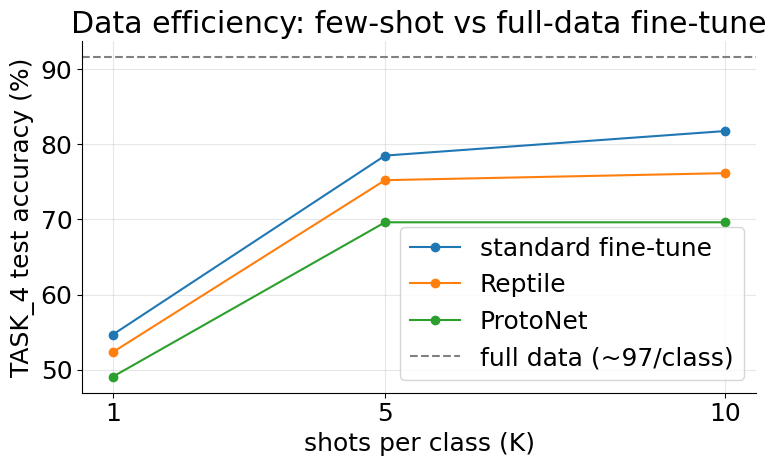

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(meta_df["K"], meta_df["standard"] * 100, marker="o", label="standard fine-tune")
ax.plot(meta_df["K"], meta_df["reptile"]  * 100, marker="o", label="Reptile")
ax.plot(meta_df["K"], meta_df["protonet"] * 100, marker="o", label="ProtoNet")
ax.axhline(acc_full * 100, ls="--", color="gray", label=f"full data (~{SHOTS_FULL:.0f}/class)")
ax.set_xlabel("shots per class (K)")
ax.set_ylabel("TASK_4 test accuracy (%)")
ax.set_title("Data efficiency: few-shot vs full-data fine-tune")
ax.set_xticks(meta_df["K"])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{cfg.RESULTS_DIR}/stage7_fewshot.png", dpi=150, bbox_inches="tight")
plt.show()

## **Save**

In [20]:
payload = {"stage": "7_meta_learning", "classes": cfg.TASK_4,
           "full_acc": float(acc_full), "shots_full": float(SHOTS_FULL),
           "trials": TRIALS}
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
with open(f"{cfg.RESULTS_DIR}/stage7_fewshot.json", "w") as f:
    json.dump(payload, f, indent=2, default=float)
print(f"Saved -> {cfg.RESULTS_DIR}/stage7_fewshot.json")

Saved -> /content/drive/MyDrive/apai/results/stage7_fewshot.json
